In [3]:
# 0) Extrair o ZIP no Colab (/content) e rodar com seus paths

import os, zipfile

ZIP_PATH = "/content/template_matching_assets.zip"
EXTRACT_DIR = "/content/template_matching_assets"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extraído em:", EXTRACT_DIR)
print("Arquivos:", os.listdir(EXTRACT_DIR))


Extraído em: /content/template_matching_assets
Arquivos: ['imagem_alvo.png', 'template_objeto_mask.png', 'run_match.py', 'template_objeto.png']


Melhor match: x=167, y=80, w=64, h=64, score=0.9826


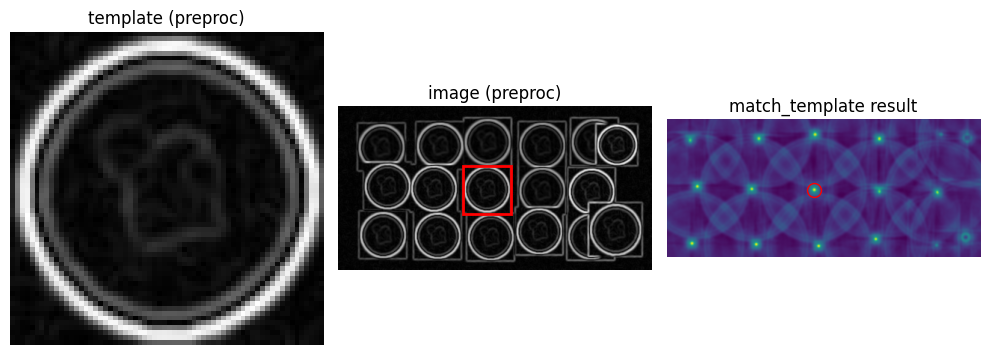


Candidatos:
  x=167, y=80, score=0.9826
  x=34, y=76, score=0.9402
  x=96, y=79, score=0.9331
  x=307, y=83, score=0.8054
  x=241, y=82, score=0.7043


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color, img_as_float
from skimage.feature import match_template, peak_local_max
from skimage.filters import gaussian, sobel
from matplotlib.patches import Rectangle


# -----------------------------
# 1) Pré-processamento
# -----------------------------
def preprocess_for_matching(image_gray: np.ndarray) -> np.ndarray:
    """
    Suavização leve -> bordas (Sobel) -> normalização [0,1]
    """
    smoothed = gaussian(image_gray, sigma=1.0, preserve_range=True)
    edges = sobel(smoothed).astype(np.float32)

    edges -= edges.min()
    edges /= (edges.max() - edges.min() + 1e-9)
    return edges


# -----------------------------
# 2) Localização por correlação
# -----------------------------
def locate_template(
    image: np.ndarray,
    template: np.ndarray,
    *,
    max_peaks: int = 5,
    min_distance: int = 10,
    threshold_rel: float = 0.6,
) -> dict:
    """
    Retorna mapa de correlação, lista de candidatos e melhor match.
    """
    result = match_template(image, template)

    peaks_rc = peak_local_max(
        result,
        num_peaks=max_peaks,
        min_distance=min_distance,
        threshold_rel=threshold_rel,
    )

    candidates = [
        {"row": int(r), "col": int(c), "score": float(result[r, c])}
        for (r, c) in peaks_rc
    ]
    candidates.sort(key=lambda x: x["score"], reverse=True)

    best = candidates[0] if candidates else None
    return {"result": result, "candidates": candidates, "best": best}


# -----------------------------
# 3) Script principal
# -----------------------------
def main():
    BASE_DIR = "/content/template_matching_assets"
    IMAGE_PATH = os.path.join(BASE_DIR, "imagem_alvo.png")
    TEMPLATE_PATH = os.path.join(BASE_DIR, "template_objeto.png")

    # valida paths
    if not os.path.exists(IMAGE_PATH):
        raise FileNotFoundError(f"Imagem não encontrada: {IMAGE_PATH}")
    if not os.path.exists(TEMPLATE_PATH):
        raise FileNotFoundError(f"Template não encontrado: {TEMPLATE_PATH}")

    # Carrega imagem e template
    image = io.imread(IMAGE_PATH)
    template = io.imread(TEMPLATE_PATH)

    # Converte para grayscale float
    image_gray = img_as_float(color.rgb2gray(image)) if image.ndim == 3 else img_as_float(image)
    template_gray = img_as_float(color.rgb2gray(template)) if template.ndim == 3 else img_as_float(template)

    # Pré-processamento igual nos dois
    image_proc = preprocess_for_matching(image_gray)
    template_proc = preprocess_for_matching(template_gray)

    # Matching
    out = locate_template(
        image_proc,
        template_proc,
        max_peaks=5,
        min_distance=max(5, template_proc.shape[0] // 2),
        threshold_rel=0.6,
    )

    best = out["best"]
    h, w = template_proc.shape

    if best is None:
        print("Nenhum match encontrado.")
        print("Tente: reduzir threshold_rel (ex: 0.4) ou revisar pré-processamento.")
        return

    y, x = best["row"], best["col"]
    print(f"Melhor match: x={x}, y={y}, w={w}, h={h}, score={best['score']:.4f}")

    # Plot (3 painéis)
    fig = plt.figure(figsize=(10, 4))
    ax1 = plt.subplot(1, 3, 1)
    ax2 = plt.subplot(1, 3, 2)
    ax3 = plt.subplot(1, 3, 3)

    ax1.imshow(template_proc, cmap="gray")
    ax1.set_title("template (preproc)")
    ax1.set_axis_off()

    ax2.imshow(image_proc, cmap="gray")
    ax2.set_title("image (preproc)")
    ax2.set_axis_off()
    ax2.add_patch(Rectangle((x, y), w, h, edgecolor="r", facecolor="none", linewidth=2))

    ax3.imshow(out["result"], cmap="viridis")
    ax3.set_title("match_template result")
    ax3.set_axis_off()
    ax3.plot(x, y, "o", markeredgecolor="r", markerfacecolor="none", markersize=10)

    plt.tight_layout()
    plt.show()

    print("\nCandidatos:")
    for c in out["candidates"]:
        print(f"  x={c['col']}, y={c['row']}, score={c['score']:.4f}")


if __name__ == "__main__":
    main()
